### Boosting Algorithms Implemented in this Notebook:

- AdaBoost (Adaptive Boosting): The classic algorithm that tweaks the weights of misclassified instances so subsequent learners focus on "hard" cases.

- Gradient Boosting (GBM): Builds trees sequentially, where each new tree tries to correct the residual errors (the difference between predicted and actual) of the previous trees.

- XGBoost (Extreme Gradient Boosting): The industry standard. It is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable.

- LightGBM: Developed by Microsoft. It uses a leaf-wise growth strategy (rather than level-wise), making it faster and more memory-efficient for large datasets.

- CatBoost: Developed by Yandex. It handles categorical data automatically (though we use numerical data here) and builds symmetric trees, which helps prevent overfitting.

#### 1) Importing Necessary Libraries:

##### 1) Installing Libraries:

Run following code to install 'xgboost' library:

!pip install xgboost

Run following code to install 'lightgbm' library:

!pip install lightgbm

Run following code to install 'catboost' library:

!pip install catboost

##### 2) Importing libraries:

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

#### 2) Data Generation:

In [6]:
X, y = make_classification(n_samples= 10000,
                          n_features= 20,
                          n_informative= 15,
                          n_redundant= 5,
                          random_state= 42)

In [7]:
X

array([[  1.0066906 ,   0.40535402,   0.45972838, ...,   1.36273455,
          1.2718852 ,  -1.27004543],
       [  3.20361849,  -0.707863  ,  -0.159855  , ...,   0.24223595,
          3.27233622, -12.61574921],
       [  0.08083857,  -1.29733668,   5.95839033, ...,  -2.80354839,
          1.31491339, -16.0431802 ],
       ...,
       [  2.54541477,   1.24540612,  -2.97974416, ...,   0.79300517,
         -2.87988532,   6.53447619],
       [ -0.08806484,   0.24743861,   5.39447635, ...,  -5.28256486,
          0.09068846,  -9.07602359],
       [  4.84897237,   2.7975459 ,  -4.37699838, ...,   1.68960533,
          1.13020495,  -0.94703559]], shape=(10000, 20))

In [8]:
print(X.shape)

(10000, 20)


In [9]:
y

array([1, 1, 0, ..., 0, 0, 1], shape=(10000,))

In [10]:
print(y.shape)

(10000,)


#### 3) Train Test Split:

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 20)
(2000, 20)
(8000,)
(2000,)


#### 4) Models:

In [16]:
# # Creating a dictionary of models for looping:

models = {
    # Focuses on weighting misclassified samples heavily
    'AdaBoost': AdaBoostClassifier(n_estimators= 100, 
                                  random_state= 42),

    # Optimizes a loss function (Log Loss) sequentially
    'GradientBoost': GradientBoostingClassifier(n_estimators= 100,
                                               loss= 'log_loss',
                                               learning_rate= 0.1,
                                               random_state= 42),

    # Includes regularization (L1/L2) to reduce overfitting
    'XGBoost': XGBClassifier(n_estimators= 100,
                            learning_rate= 0.1,
                            eval_metric= 'logloss',
                            random_state= 42),

    # Histogram-based, leaf-wise growth (very fast)
    'LightGBM': LGBMClassifier(n_estimators= 100,
                              learning_rate= 0.1,
                              random_state= 42,
                              verbosity= -1),

    # Ordered boosting, symmetric trees
    'CatBoost': CatBoostClassifier(n_estimators= 100,
                                  learning_rate= 0.1,
                                  random_state= 42,
                                  verbose= 0)
}

In [17]:
# Model Training and Evaluation:

results = []

for name, model in models.items():
    model.fit(X_train, y_train) # Fitting the model
    y_pred = model.predict(X_test) # Predictions using the model
    acc = accuracy_score(y_test, y_pred) # Model Accuracy
    results.append({'Algorithm': name, 'Accuracy': acc})
    print(f"{name:<35} | {acc:.4f}")

AdaBoost                            | 0.7995
GradientBoost                       | 0.9180
XGBoost                             | 0.9500


C:\Users\shail\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM                            | 0.9540
CatBoost                            | 0.9555


#### 5) Results Visualization:

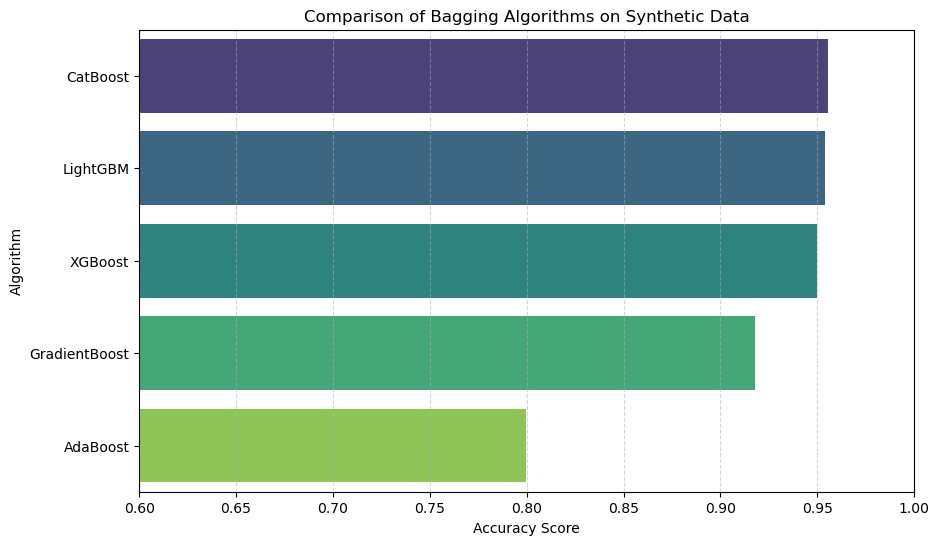

In [19]:
df_results = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

plt.figure(figsize= (10, 6))
sns.barplot(x= 'Accuracy', y= 'Algorithm', data= df_results, palette= 'viridis', hue= 'Algorithm')
plt.title('Comparison of Bagging Algorithms on Synthetic Data')
plt.xlabel('Accuracy Score')
plt.xlim(0.6, 1.0) # Zoom in to see differences
plt.grid(axis= 'x', linestyle= '--', alpha= 0.5)
plt.show()

#### 6) Best Model and Report of Evaluation:

In [20]:
best_model_name = df_results.iloc[0]['Algorithm']
print(f"\n{'-'*60}")
print(f"Detailed Report for Best Model: {best_model_name}")
print(f"{'-'*60}")
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))


------------------------------------------------------------
Detailed Report for Best Model: CatBoost
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      1001
           1       0.97      0.94      0.95       999

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000

